In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from zipfile import ZipFile
from urllib.request import urlretrieve
from IPython.display import Image
%matplotlib inline


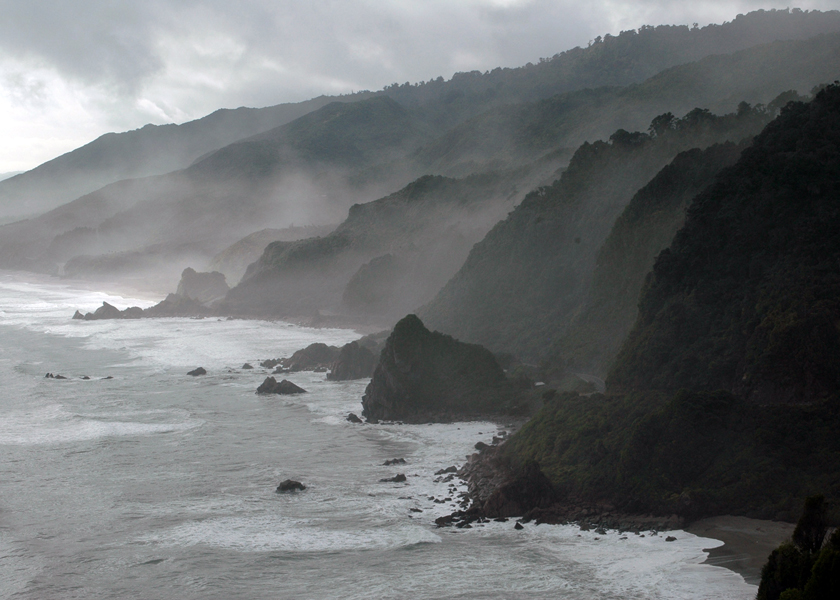

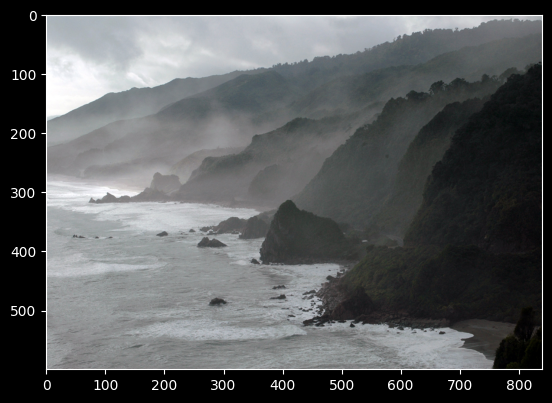

In [7]:
imagepath='C:/Users/Mohan/Downloads/opencv_bootcamp_assets_NB1/NB4/'

img_bgr=cv2.imread(imagepath+'New_Zealand_Coast.jpg',cv2.IMREAD_COLOR)
img_rgb=cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
Image(imagepath+'New_Zealand_Coast.jpg')

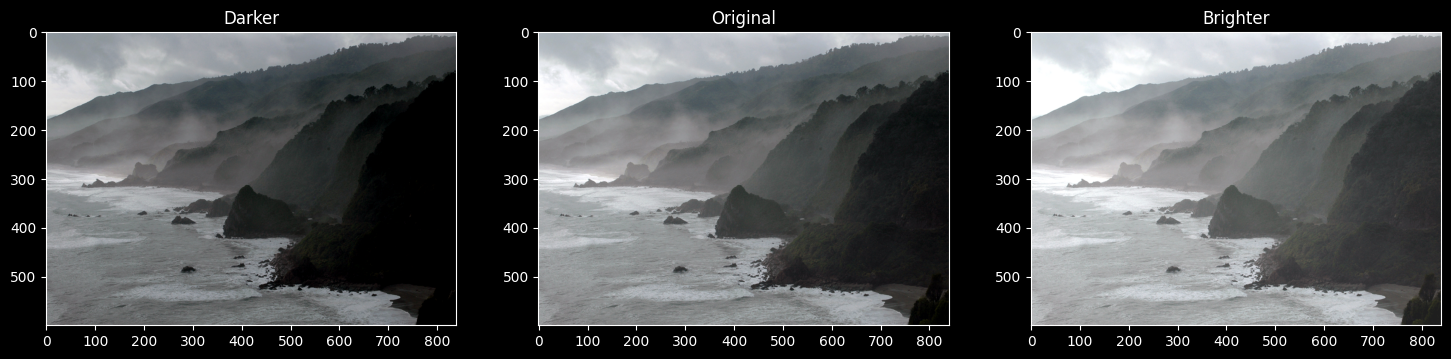

In [12]:
#Addition or brightness
matrix=np.ones(img_rgb.shape,dtype='uint8')*30

img_rgb_brighter=cv2.add(img_rgb,matrix)
img_rgb_darker=cv2.subtract(img_rgb,matrix)

# Show the images
plt.figure(figsize=[18, 5])
plt.subplot(131); plt.imshow(img_rgb_darker);  plt.title("Darker");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter);plt.title("Brighter");

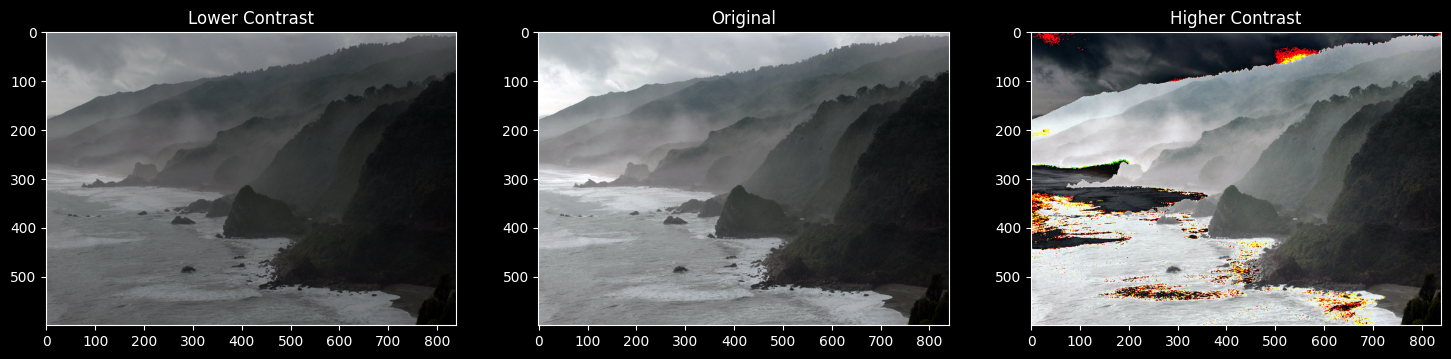

In [18]:
#Multiplication or Contrast
mul_matrix=np.ones(img_rgb.shape)*1.5
div_matrix=np.ones(img_rgb.shape)*0.7

img_rgb_darker=np.uint8(cv2.multiply(np.float64(img_rgb),div_matrix))
img_rgb_brighter=np.uint8(cv2.multiply(np.float64(img_rgb),mul_matrix))

# Show the images
plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_darker);  plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter);plt.title("Higher Contrast");

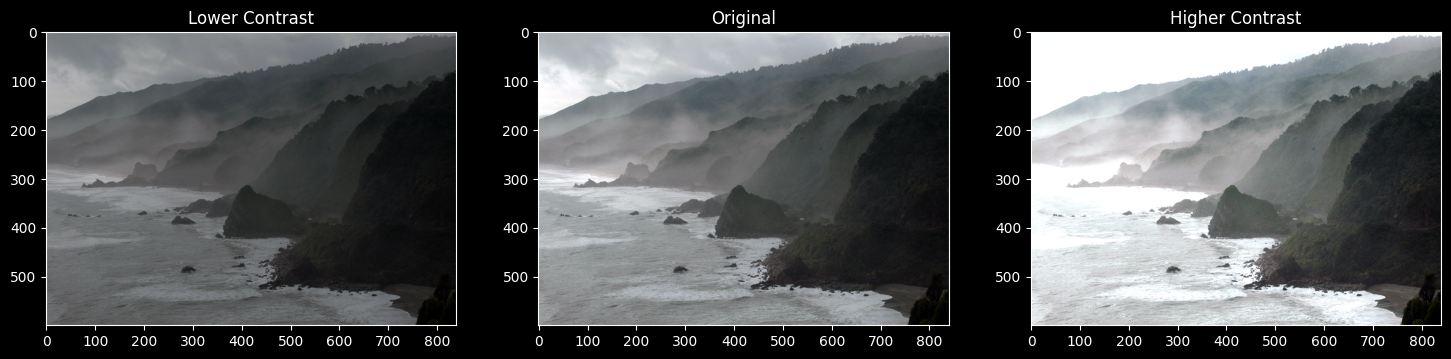

In [20]:
# Handling Overflow using np.clip
mul_matrix=np.ones(img_rgb.shape)*1.5
div_matrix=np.ones(img_rgb.shape)*0.7

img_rgb_lower=np.uint64(cv2.multiply(np.float64(img_rgb),div_matrix))
img_rgb_higher=np.uint64(np.clip(cv2.multiply(np.float64(img_rgb),mul_matrix),0,255))


# Show the images
plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_lower); plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb);       plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_higher);plt.title("Higher Contrast");

Text(0.5, 1.0, 'Thresholded')

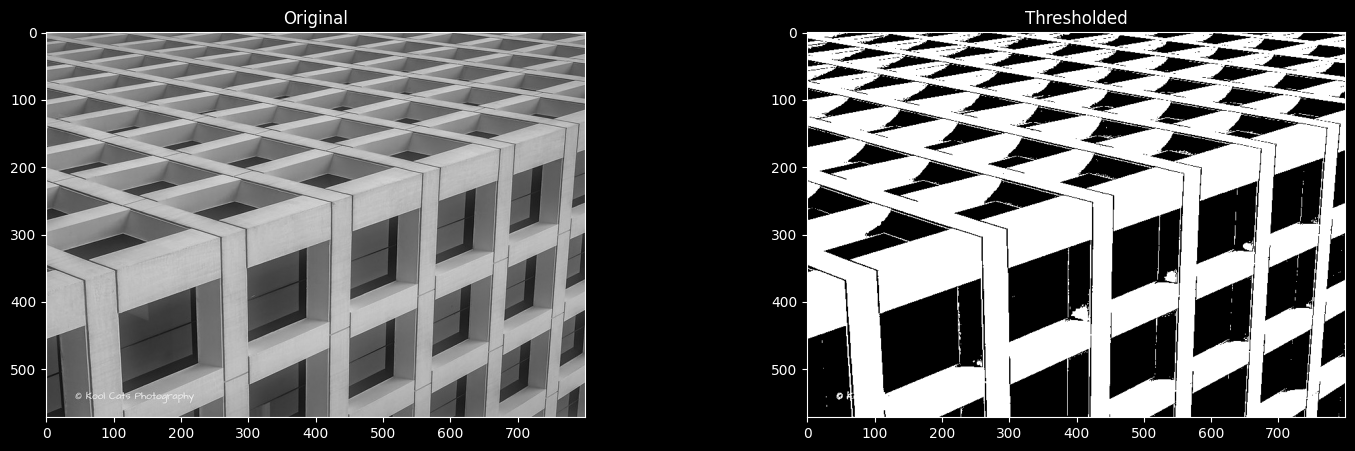

In [24]:
#Image Thresholding
img_read = cv2.imread(imagepath+"building-windows.jpg", cv2.IMREAD_GRAYSCALE)
retval, img_thresh = cv2.threshold(img_read, 120, 255, cv2.THRESH_BINARY)

# Show the images
plt.figure(figsize=[18, 5])

plt.subplot(121);plt.imshow(img_read, cmap="gray");  plt.title("Original")
plt.subplot(122);plt.imshow(img_thresh, cmap="gray");plt.title("Thresholded")

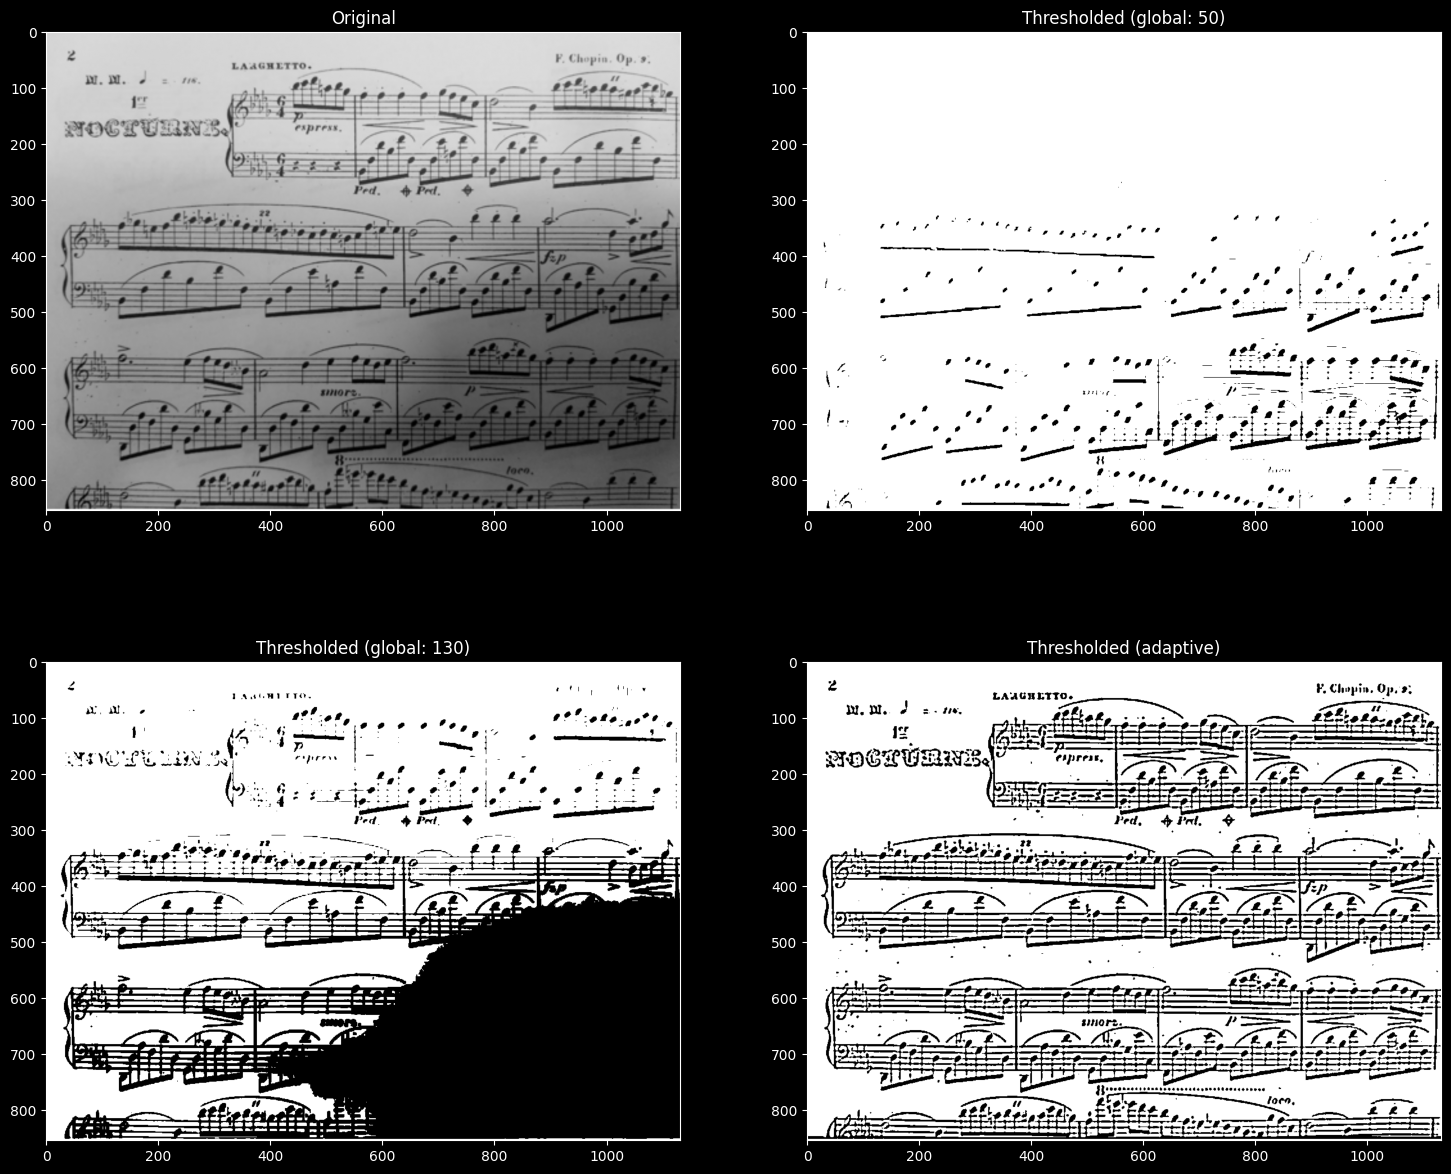

In [29]:
#Application: Sheet Music Reader
img_music=cv2.imread(imagepath+"Piano_Sheet_Music.png",cv2.IMREAD_GRAYSCALE)

# perform gloabl thresholding
retval,img_ther_glb1=cv2.threshold(img_music,40,255,cv2.THRESH_BINARY)

#perform global thresholding
retval, img_ther_glb2=cv2.threshold(img_music, 120,255,cv2.THRESH_BINARY)

#perform adoptive thresholding
img_ther_ad=cv2.adaptiveThreshold(img_music,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,11,7)

# Show the images
plt.figure(figsize=[18,15])
plt.subplot(221); plt.imshow(img_music,        cmap="gray");  plt.title("Original");
plt.subplot(222); plt.imshow(img_ther_glb1,cmap="gray");  plt.title("Thresholded (global: 50)");
plt.subplot(223); plt.imshow(img_ther_glb2,cmap="gray");  plt.title("Thresholded (global: 130)");
plt.subplot(224); plt.imshow(img_ther_ad,  cmap="gray");  plt.title("Thresholded (adaptive)");

(200, 499)
(200, 499)


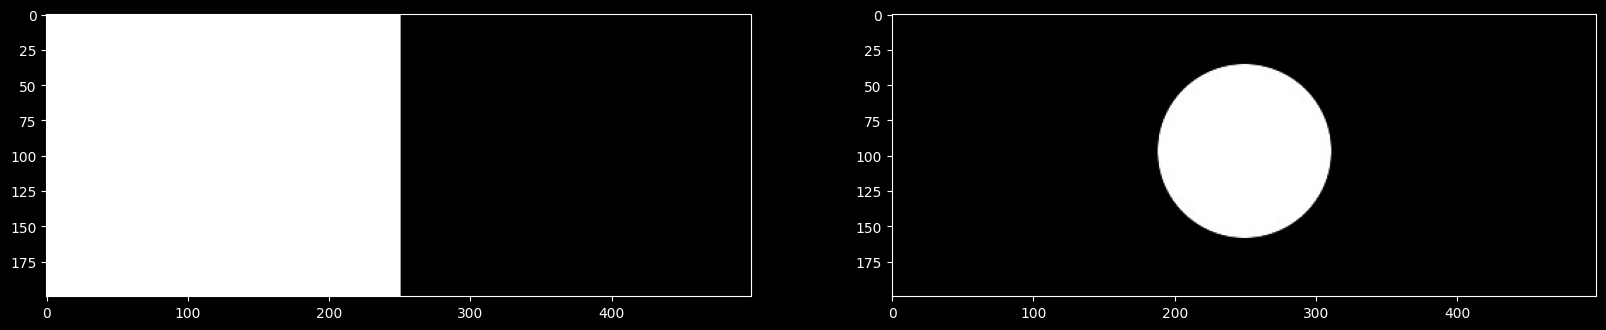

In [33]:
#Bitwise Operations
img_rec=cv2.imread(imagepath+"rectangle.jpg",cv2.IMREAD_GRAYSCALE)
img_cir=cv2.imread(imagepath+"circle.jpg",cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=[20, 5])
plt.subplot(121);plt.imshow(img_rec, cmap="gray")
plt.subplot(122);plt.imshow(img_cir, cmap="gray")
print(img_rec.shape)
print(img_cir.shape)

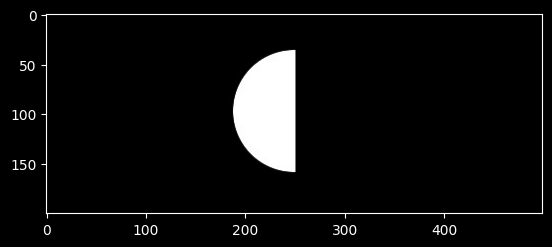

In [35]:
img_bitand=cv2.bitwise_and(img_rec,img_cir)
plt.imshow(img_bitand)
# plt.imshow(img_bitand,cmap="gray")

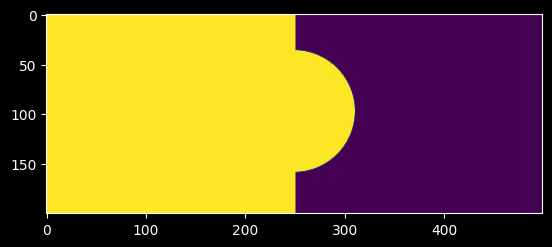

In [36]:
img_bitor=cv2.bitwise_or(img_rec,img_cir)
plt.imshow(img_bitor)

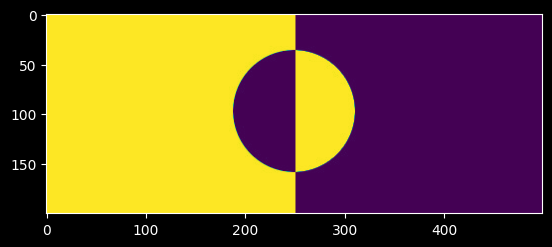

In [37]:
img_bitxor=cv2.bitwise_xor(img_rec,img_cir)
plt.imshow(img_bitxor)

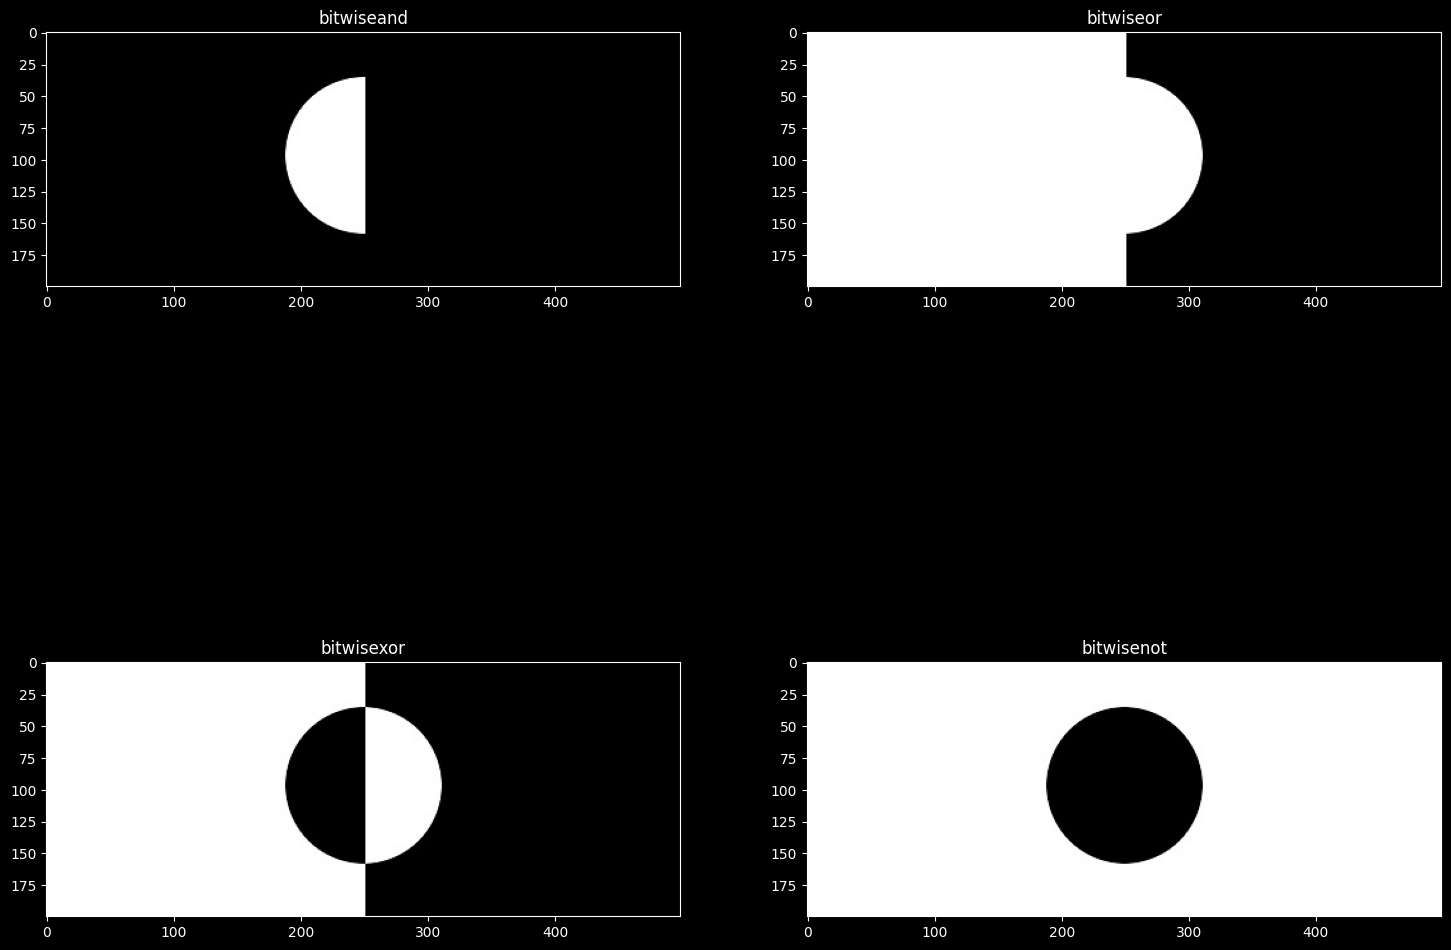

In [38]:
plt.figure(figsize=[18,15])
plt.subplot(221);plt.imshow(img_bitand,cmap="gray"); plt.title("bitwiseand");
plt.subplot(222);plt.imshow(img_bitor,cmap="gray"); plt.title("bitwiseor");
plt.subplot(223);plt.imshow(img_bitxor,cmap="gray"); plt.title("bitwisexor");
plt.subplot(224);plt.imshow(cv2.bitwise_not(img_cir),cmap="gray"); plt.title("bitwisenot");


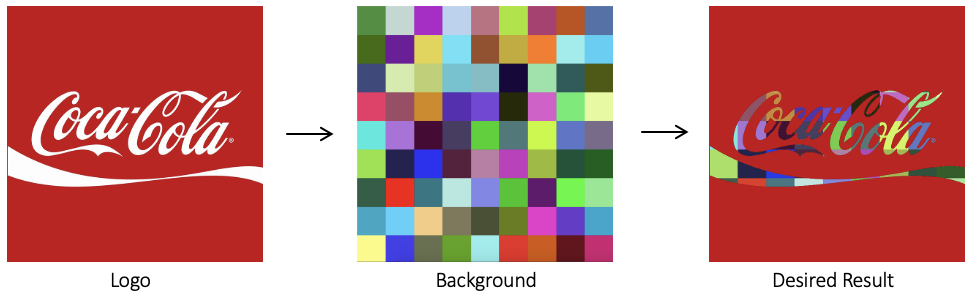

In [42]:
#Application logo manipulation
Image(imagepath+'Logo_Manipulation.png')



(700, 700, 3)


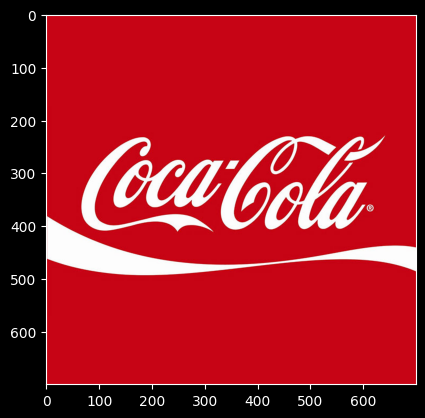

In [41]:
img_bgr = cv2.imread(imagepath+"coca-cola-logo.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

print(img_rgb.shape)

logo_w = img_rgb.shape[0]
logo_h = img_rgb.shape[1]

(700, 700, 3)


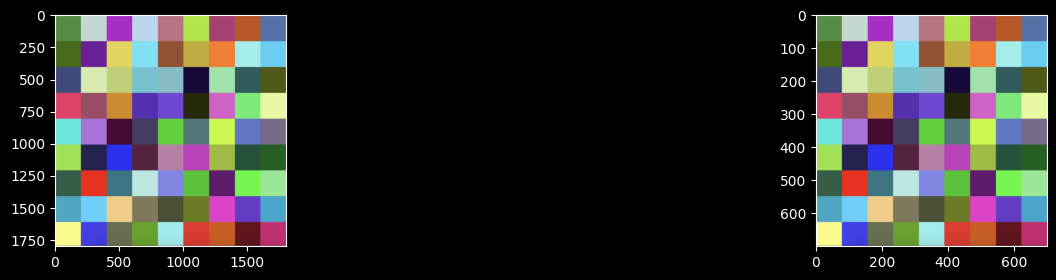

In [47]:
# Read in image of color cheackerboad background
img_background_bgr = cv2.imread(imagepath+"checkerboard_color.png")
img_background_rgb = cv2.cvtColor(img_background_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=[18, 3])
plt.subplot(121);plt.imshow(img_background_rgb)

 # Set desired width (logo_w) and maintain image aspect ratio
aspect_ratio=logo_w/img_background_rgb.shape[1]
dim=(logo_w,int(img_background_rgb.shape[0]*aspect_ratio))

# Resize background image to sae size as logo image
img_background_rgb =cv2.resize(img_background_rgb,dim,interpolation=cv2.INTER_AREA)
plt.subplot(122);plt.imshow(img_background_rgb)
print(img_background_rgb.shape)

(700, 700)


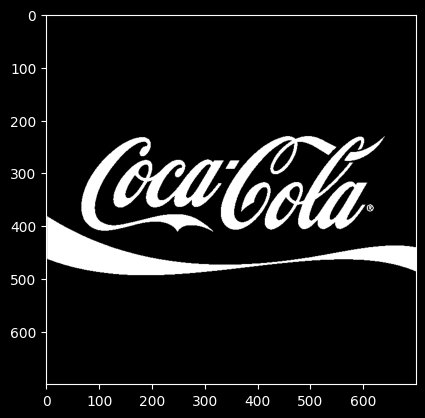

In [51]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Apply global thresholding to creat a binary mask of the logo
retval, img_mask=cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY)

plt.imshow(img_mask, cmap="gray")
print(img_mask.shape)

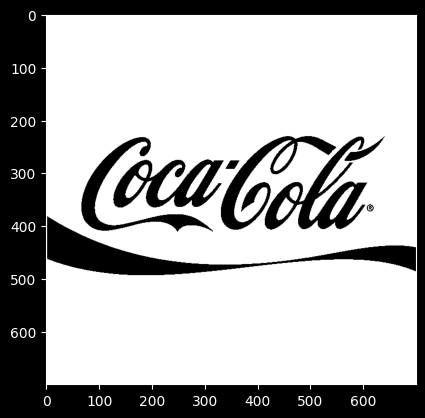

In [52]:
# Create an inverse mask
img_mask_inv = cv2.bitwise_not(img_mask)
plt.imshow(img_mask_inv, cmap="gray")

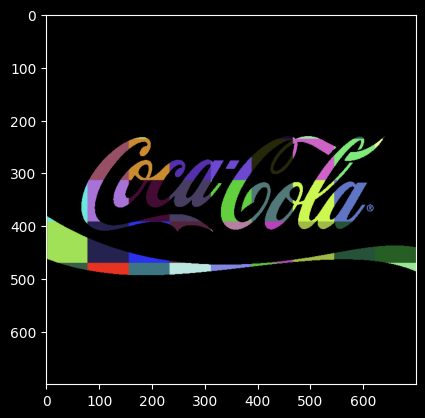

In [53]:
# Create colorful background "behind" the logo lettering
img_background=cv2.bitwise_and(img_background_rgb,img_background_rgb,mask=img_mask)
plt.imshow(img_background)

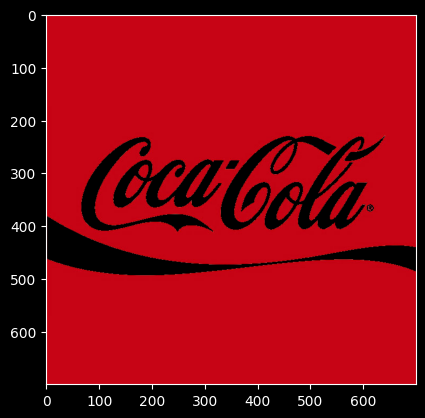

In [54]:
# Isolate foreground (red from original image) using the inverse mask
img_foreground = cv2.bitwise_and(img_rgb, img_rgb, mask=img_mask_inv)
plt.imshow(img_foreground)

True

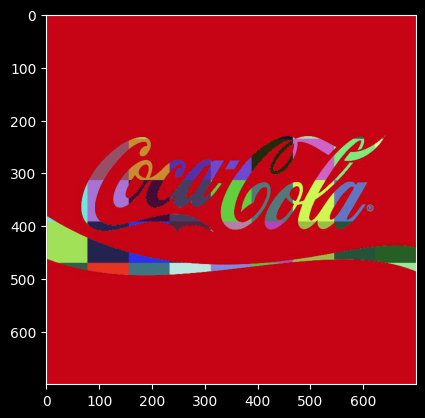

In [56]:
# Add the two previous results obtain the final result
result = cv2.add(img_background, img_foreground)
plt.imshow(result)
cv2.imwrite(imagepath+"logo_final.png", result[:, :, ::-1])

In [60]:
arr1=np.array([200,250],dtype=np.uint8).reshape([-1,1])
print(arr1)
arr2=np.array([40,40],dtype=np.uint8).reshape([-1,1])
print(arr2)
add_nu=arr1+arr2
print(add_nu)
print(cv2.add(arr1,arr2))

[[200]
 [250]]
[[40]
 [40]]
[[240]
 [ 34]]
[[240]
 [255]]


In [66]:
arr=[[1,1,1],[1,0,0],[0,0,0]]
arr2=[[1,1,0],[1,1,0],[1,0,0]]
print(arr)
print(arr2)
print(cv2.bitwise_and(np.array(arr),np.array(arr2)))

[[1, 1, 1], [1, 0, 0], [0, 0, 0]]
[[1, 1, 0], [1, 1, 0], [1, 0, 0]]
[[1 1 0]
 [1 0 0]
 [0 0 0]]
